# Chapter 43 — Recovering Division Daughters Before Tracking

Chapter 42 identified two different failure modes around the known GT division:

- **Daughter A:** Chapter 34 had a substantially better candidate, but Chapter 36 filtering removed it.
- **Daughter B:** Chapter 34 was already weak at the exact GT frame, but a much better candidate appeared one frame later.

This notebook focuses on the stage **before tracking**.

The goal is to determine whether we can rescue likely daughter detections before Chapter 37 so the tracker receives better inputs.

## Known GT division

```text
GT parent:      172000000050   t=66
GT daughter A:  173000000050   t=67
GT daughter B:  173000000051   t=67
```

## Inputs

```text
/kaggle/input/datasets/emailchrismathews/data34
/kaggle/input/datasets/emailchrismathews/data36
/kaggle/input/datasets/emailchrismathews/data37
Biohub competition training data
```

## Main outputs

```text
chapter43_daughter_candidate_audit.csv
chapter43_filtered_out_daughter_candidates.csv
chapter43_rescued_detections.csv
chapter43_rescued_detection_set.csv
chapter43_rescue_summary.csv
chapter43_rescue_validation.csv
chapter43_outputs.zip
```

This notebook is diagnostic and experimental. It does **not** overwrite Chapter 36 outputs.

In [1]:

!pip install -q zarr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 77.1 MB/s eta 0:00:00


In [2]:

from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import shutil
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zarr

from IPython.display import display

warnings.filterwarnings("ignore")

## Step 1 — Configuration

In [3]:

@dataclass(frozen=True)
class Config:
    sample_id: str = "44b6_12dfb391"
    z_scale: float = 1.625
    y_scale: float = 0.40625
    x_scale: float = 0.40625
    division_parent_t: int = 66
    division_daughter_t: int = 67
    trace_start_t: int = 65
    trace_end_t: int = 69
    nearest_k: int = 40
    exact_frame_radius: float = 12.0
    nearby_frame_radius: float = 10.0
    max_temporal_offset: int = 2
    rescue_top_k_per_role: int = 3
    useful_distance_physical: float = 10.0

CONFIG = Config()

DATA34_DIR = Path("/kaggle/input/datasets/emailchrismathews/data34")
DATA36_DIR = Path("/kaggle/input/datasets/emailchrismathews/data36")
DATA37_DIR = Path("/kaggle/input/datasets/emailchrismathews/data37")
OUTPUT_DIR = Path("/kaggle/working")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(CONFIG)
print()
print("data34:", DATA34_DIR.exists())
print("data36:", DATA36_DIR.exists())
print("data37:", DATA37_DIR.exists())

Config(sample_id='44b6_12dfb391', z_scale=1.625, y_scale=0.40625, x_scale=0.40625, division_parent_t=66, division_daughter_t=67, trace_start_t=65, trace_end_t=69, nearest_k=40, exact_frame_radius=12.0, nearby_frame_radius=10.0, max_temporal_offset=2, rescue_top_k_per_role=3, useful_distance_physical=10.0)

data34: True
data36: True
data37: True


## Step 2 — Locate and load Chapter 34, Chapter 36, and Chapter 37

In [4]:

def require_file(folder, filename):
    path = Path(folder) / filename
    if path.exists():
        return path
    matches = list(Path(folder).rglob(filename))
    if matches:
        return sorted(matches, key=lambda p: len(str(p)))[0]
    raise FileNotFoundError(f"Could not find {filename} in {folder}")

chapter34_path = require_file(DATA34_DIR, "chapter34_top200_detections.csv")
chapter36_path = require_file(DATA36_DIR, "chapter36_filtered_detections.csv")
chapter37_path = require_file(DATA37_DIR, "chapter37_refined_track_nodes.csv")

chapter34_df = pd.read_csv(chapter34_path)
chapter36_df = pd.read_csv(chapter36_path)
chapter37_df = pd.read_csv(chapter37_path)

print("Chapter 34 rows:", len(chapter34_df))
print("Chapter 36 rows:", len(chapter36_df))
print("Chapter 37 rows:", len(chapter37_df))
print()
print("Chapter 34 path:", chapter34_path)
print("Chapter 36 path:", chapter36_path)
print("Chapter 37 path:", chapter37_path)

Chapter 34 rows: 20000
Chapter 36 rows: 5000
Chapter 37 rows: 4642

Chapter 34 path: /kaggle/input/datasets/emailchrismathews/data34/chapter34_top200_detections.csv
Chapter 36 path: /kaggle/input/datasets/emailchrismathews/data36/chapter36_filtered_detections.csv
Chapter 37 path: /kaggle/input/datasets/emailchrismathews/data37/chapter37_refined_track_nodes.csv


## Step 3 — Load the known GT division

In [5]:

def find_geff_path(sample_id):
    expected = Path(
        "/kaggle/input/competitions/biohub-cell-tracking-during-development/train"
    ) / f"{sample_id}.geff"
    if expected.exists():
        return expected
    matches = list(Path("/kaggle/input").rglob(f"{sample_id}.geff"))
    if matches:
        return sorted(matches, key=lambda p: len(str(p)))[0]
    raise FileNotFoundError(f"Could not find GEFF file for {sample_id}")

geff_path = find_geff_path(CONFIG.sample_id)
geff = zarr.open(geff_path, mode="r")

gt_nodes_df = pd.DataFrame({
    "gt_node_id": np.asarray(geff["nodes/ids"][:]),
    "t": np.asarray(geff["nodes/props/t/values"][:]).astype(int),
    "z": np.asarray(geff["nodes/props/z/values"][:]).astype(float),
    "y": np.asarray(geff["nodes/props/y/values"][:]).astype(float),
    "x": np.asarray(geff["nodes/props/x/values"][:]).astype(float),
})

edge_ids = np.asarray(geff["edges/ids"][:])
gt_edges_df = pd.DataFrame({"gt_source": edge_ids[:,0], "gt_target": edge_ids[:,1]})
out_degree = gt_edges_df.groupby("gt_source").size()
division_parents = out_degree[out_degree == 2].index.tolist()

division_rows=[]
for parent in division_parents:
    daughters = sorted(gt_edges_df.loc[gt_edges_df["gt_source"]==parent,"gt_target"].tolist())
    if len(daughters)!=2:
        continue
    p = gt_nodes_df[gt_nodes_df["gt_node_id"]==parent]
    a = gt_nodes_df[gt_nodes_df["gt_node_id"]==daughters[0]]
    b = gt_nodes_df[gt_nodes_df["gt_node_id"]==daughters[1]]
    if p.empty or a.empty or b.empty:
        continue
    p,a,b = p.iloc[0],a.iloc[0],b.iloc[0]
    division_rows.append({
        "gt_parent":parent,"gt_daughter_a":daughters[0],"gt_daughter_b":daughters[1],
        "parent_t":int(p["t"]),"daughter_t_a":int(a["t"]),"daughter_t_b":int(b["t"]),
        "parent_z":float(p["z"]),"parent_y":float(p["y"]),"parent_x":float(p["x"]),
        "daughter_a_z":float(a["z"]),"daughter_a_y":float(a["y"]),"daughter_a_x":float(a["x"]),
        "daughter_b_z":float(b["z"]),"daughter_b_y":float(b["y"]),"daughter_b_x":float(b["x"]),
    })

gt_divisions_df = pd.DataFrame(division_rows)
if gt_divisions_df.empty:
    raise RuntimeError("No GT division found.")
division = gt_divisions_df.iloc[0]
display(gt_divisions_df)

,gt_parent,gt_daughter_a,gt_daughter_b,parent_t,daughter_t_a,daughter_t_b,parent_z,parent_y,parent_x,daughter_a_z,daughter_a_y,daughter_a_x,daughter_b_z,daughter_b_y,daughter_b_x
0,172000000050,173000000050,173000000051,66,67,67,46.0,63.0,160.0,46.0,51.0,160.0,46.0,74.0,164.0


## Step 4 — Add physical coordinates

In [6]:

def add_physical_coordinates(df):
    result = df.copy()
    result["z_physical"] = result["z"].astype(float) * CONFIG.z_scale
    result["y_physical"] = result["y"].astype(float) * CONFIG.y_scale
    result["x_physical"] = result["x"].astype(float) * CONFIG.x_scale
    return result

chapter34_df = add_physical_coordinates(chapter34_df)
chapter36_df = add_physical_coordinates(chapter36_df)
chapter37_df = add_physical_coordinates(chapter37_df)

gt_role_df = pd.DataFrame([
    {"role":"parent","gt_node_id":division["gt_parent"],"t":int(division["parent_t"]),"z":float(division["parent_z"]),"y":float(division["parent_y"]),"x":float(division["parent_x"])},
    {"role":"daughter_a","gt_node_id":division["gt_daughter_a"],"t":int(division["daughter_t_a"]),"z":float(division["daughter_a_z"]),"y":float(division["daughter_a_y"]),"x":float(division["daughter_a_x"])},
    {"role":"daughter_b","gt_node_id":division["gt_daughter_b"],"t":int(division["daughter_t_b"]),"z":float(division["daughter_b_z"]),"y":float(division["daughter_b_y"]),"x":float(division["daughter_b_x"])},
])
gt_role_df = add_physical_coordinates(gt_role_df)
display(gt_role_df)

,role,gt_node_id,t,z,y,x,z_physical,y_physical,x_physical
0,parent,1.720000e+11,66,46.0,63.0,160.0,74.75,25.59375,65.000
1,daughter_a,1.730000e+11,67,46.0,51.0,160.0,74.75,20.71875,65.000
2,daughter_b,1.730000e+11,67,46.0,74.0,164.0,74.75,30.06250,66.625


## Step 5 — Compare Chapter 34 and Chapter 36 candidates near both daughters

In [7]:

def nearest_candidates(df, stage, role_row, start_t, end_t, nearest_k):
    local = df[df["t"].between(start_t,end_t)].copy()
    if local.empty:
        return pd.DataFrame()
    gt_xyz=np.array([role_row["z_physical"],role_row["y_physical"],role_row["x_physical"]])
    pred_xyz=local[["z_physical","y_physical","x_physical"]].to_numpy(dtype=float)
    local["distance_to_gt_physical"] = np.linalg.norm(pred_xyz-gt_xyz[None,:],axis=1)
    local["temporal_offset"] = local["t"].astype(int)-int(role_row["t"])
    local["abs_temporal_offset"] = local["temporal_offset"].abs()
    local["trace_score"] = local["distance_to_gt_physical"] + 2.0*local["abs_temporal_offset"]
    local["stage"] = stage
    local["role"] = role_row["role"]
    local["gt_node_id"] = role_row["gt_node_id"]
    return local.sort_values(["trace_score","distance_to_gt_physical"]).head(nearest_k).reset_index(drop=True)

audit_tables=[]
for role in ["daughter_a","daughter_b"]:
    role_row = gt_role_df[gt_role_df["role"]==role].iloc[0]
    for stage,df in [("chapter34",chapter34_df),("chapter36",chapter36_df)]:
        result=nearest_candidates(df,stage,role_row,CONFIG.trace_start_t,CONFIG.trace_end_t,CONFIG.nearest_k)
        if not result.empty:
            audit_tables.append(result)

daughter_candidate_audit_df = pd.concat(audit_tables,ignore_index=True) if audit_tables else pd.DataFrame()
cols=[c for c in ["stage","role","t","z","y","x","distance_to_gt_physical","temporal_offset","trace_score","rank_position","filtered_rank_position","final_filter_score","pred_dist","detection_id"] if c in daughter_candidate_audit_df.columns]
display(daughter_candidate_audit_df[cols].head(50))

,stage,role,t,z,y,x,distance_to_gt_physical,temporal_offset,trace_score,rank_position,filtered_rank_position,final_filter_score,pred_dist,detection_id
0,chapter34,daughter_a,68,42,49,161,6.563170,1,8.563170,182,NaN,NaN,17.720959,chapter34_t68_181
1,chapter34,daughter_a,67,40,46,158,9.992429,0,9.992429,192,NaN,NaN,17.764170,chapter34_t67_191
2,chapter34,daughter_a,65,42,46,164,7.001186,-2,11.001186,179,NaN,NaN,17.865746,chapter34_t65_178
3,chapter34,daughter_a,65,51,45,158,8.521572,-2,12.521572,125,NaN,NaN,17.530287,chapter34_t65_124
4,chapter34,daughter_a,65,51,42,156,9.056733,-2,13.056733,70,NaN,NaN,16.911856,chapter34_t65_69
5,chapter34,daughter_a,68,42,78,166,12.980943,1,14.980943,102,NaN,NaN,17.011053,chapter34_t68_101
6,chapter34,daughter_a,65,53,51,165,11.554938,-2,15.554938,186,NaN,NaN,17.908640,chapter34_t65_185
7,chapter34,daughter_a,68,42,35,133,14.311306,1,16.311306,153,NaN,NaN,17.494432,chapter34_t68_152
8,chapter34,daughter_a,67,46,12,150,16.356293,0,16.356293,144,NaN,NaN,17.391140,chapter34_t67_143
9,chapter34,daughter_a,69,38,45,164,13.325991,2,17.325991,130,NaN,NaN,17.638536,chapter34_t69_129


## Step 6 — Match Chapter 34 detections to Chapter 36 survivors

In [8]:

chapter36_key_set=set(zip(chapter36_df["t"].astype(int),chapter36_df["z"].astype(float),chapter36_df["y"].astype(float),chapter36_df["x"].astype(float)))
chapter34_df["survived_chapter36"]=[(int(t),float(z),float(y),float(x)) in chapter36_key_set for t,z,y,x in zip(chapter34_df["t"],chapter34_df["z"],chapter34_df["y"],chapter34_df["x"])]
print("Chapter 34 detections surviving Chapter 36:",int(chapter34_df["survived_chapter36"].sum()),"/",len(chapter34_df))

Chapter 34 detections surviving Chapter 36: 5000 / 20000


## Step 7 — Identify daughter-like Chapter 34 detections that were filtered out

In [9]:

filtered_out_rows=[]
for role in ["daughter_a","daughter_b"]:
    role_row=gt_role_df[gt_role_df["role"]==role].iloc[0]
    local=chapter34_df[chapter34_df["t"].between(CONFIG.trace_start_t,CONFIG.trace_end_t)].copy()
    gt_xyz=np.array([role_row["z_physical"],role_row["y_physical"],role_row["x_physical"]])
    pred_xyz=local[["z_physical","y_physical","x_physical"]].to_numpy(dtype=float)
    local["distance_to_gt_physical"] = np.linalg.norm(pred_xyz-gt_xyz[None,:],axis=1)
    local["temporal_offset"] = local["t"].astype(int)-int(role_row["t"])
    local["abs_temporal_offset"] = local["temporal_offset"].abs()
    local["trace_score"] = local["distance_to_gt_physical"] + 2.0*local["abs_temporal_offset"]
    local["role"] = role
    local["gt_node_id"] = role_row["gt_node_id"]
    local=local[(local["distance_to_gt_physical"]<=CONFIG.nearby_frame_radius)&(local["abs_temporal_offset"]<=CONFIG.max_temporal_offset)].copy()
    local["rescue_candidate"] = ~local["survived_chapter36"]
    filtered_out_rows.append(local)
filtered_out_audit_df = pd.concat(filtered_out_rows,ignore_index=True) if filtered_out_rows else pd.DataFrame()
cols=[c for c in ["role","t","z","y","x","distance_to_gt_physical","temporal_offset","trace_score","survived_chapter36","rescue_candidate","rank_position","pred_dist","detection_id"] if c in filtered_out_audit_df.columns]
display(filtered_out_audit_df[cols].sort_values(["role","trace_score"]))

,role,t,z,y,x,distance_to_gt_physical,temporal_offset,trace_score,survived_chapter36,rescue_candidate,rank_position,pred_dist,detection_id
4,daughter_a,68,42,49,161,6.563170,1,8.563170,False,True,182,17.720959,chapter34_t68_181
3,daughter_a,67,40,46,158,9.992429,0,9.992429,False,True,192,17.764170,chapter34_t67_191
2,daughter_a,65,42,46,164,7.001186,-2,11.001186,False,True,179,17.865746,chapter34_t65_178
1,daughter_a,65,51,45,158,8.521572,-2,12.521572,False,True,125,17.530287,chapter34_t65_124
0,daughter_a,65,51,42,156,9.056733,-2,13.056733,False,True,70,16.911856,chapter34_t65_69
5,daughter_b,68,42,78,166,6.749132,1,8.749132,False,True,102,17.011053,chapter34_t68_101


## Step 8 — Create a conservative rescue rule

In [10]:

rescue_rows=[]
for role in ["daughter_a","daughter_b"]:
    subset=filtered_out_audit_df[(filtered_out_audit_df["role"]==role)&(filtered_out_audit_df["rescue_candidate"])].copy()
    if subset.empty:
        continue
    subset=subset.sort_values(["trace_score","distance_to_gt_physical"]).head(CONFIG.rescue_top_k_per_role)
    rescue_rows.append(subset)
rescued_detections_df = pd.concat(rescue_rows,ignore_index=True) if rescue_rows else pd.DataFrame()
if not rescued_detections_df.empty:
    rescued_detections_df["rescue_source"]="chapter34_filtered_out"
cols=[c for c in ["role","t","z","y","x","distance_to_gt_physical","temporal_offset","trace_score","rank_position","pred_dist","detection_id","rescue_source"] if c in rescued_detections_df.columns]
display(rescued_detections_df[cols])

,role,t,z,y,x,distance_to_gt_physical,temporal_offset,trace_score,rank_position,pred_dist,detection_id,rescue_source
0,daughter_a,68,42,49,161,6.563170,1,8.563170,182,17.720959,chapter34_t68_181,chapter34_filtered_out
1,daughter_a,67,40,46,158,9.992429,0,9.992429,192,17.764170,chapter34_t67_191,chapter34_filtered_out
2,daughter_a,65,42,46,164,7.001186,-2,11.001186,179,17.865746,chapter34_t65_178,chapter34_filtered_out
3,daughter_b,68,42,78,166,6.749132,1,8.749132,102,17.011053,chapter34_t68_101,chapter34_filtered_out


## Step 9 — Build an experimental rescued detection set

In [11]:

if rescued_detections_df.empty:
    chapter43_rescued_detection_set_df=chapter36_df.copy()
else:
    rescue_columns=[c for c in chapter36_df.columns if c in rescued_detections_df.columns]
    rescue_for_merge=rescued_detections_df[rescue_columns].copy()
    chapter43_rescued_detection_set_df=pd.concat([chapter36_df,rescue_for_merge],ignore_index=True)
    chapter43_rescued_detection_set_df=chapter43_rescued_detection_set_df.drop_duplicates(subset=["t","z","y","x"]).reset_index(drop=True)
print("Original Chapter 36 detections:",len(chapter36_df))
print("Rescued detections added:",len(chapter43_rescued_detection_set_df)-len(chapter36_df))
print("Experimental rescued detection set:",len(chapter43_rescued_detection_set_df))

Original Chapter 36 detections: 5000
Rescued detections added: 4
Experimental rescued detection set: 5004


## Step 10 — Re-evaluate nearest daughter distances after rescue

In [12]:

def nearest_distance_at_or_near_gt(df, role_row):
    local=df[df["t"].between(int(role_row["t"])-CONFIG.max_temporal_offset,int(role_row["t"])+CONFIG.max_temporal_offset)].copy()
    if local.empty:
        return {"best_t":np.nan,"best_distance_physical":np.nan,"best_temporal_offset":np.nan}
    gt_xyz=np.array([role_row["z_physical"],role_row["y_physical"],role_row["x_physical"]])
    pred_xyz=local[["z_physical","y_physical","x_physical"]].to_numpy(dtype=float)
    local["distance_to_gt_physical"] = np.linalg.norm(pred_xyz-gt_xyz[None,:],axis=1)
    local["temporal_offset"] = local["t"].astype(int)-int(role_row["t"])
    local["trace_score"] = local["distance_to_gt_physical"] + 2.0*local["temporal_offset"].abs()
    best=local.sort_values(["trace_score","distance_to_gt_physical"]).iloc[0]
    return {"best_t":int(best["t"]),"best_distance_physical":float(best["distance_to_gt_physical"]),"best_temporal_offset":int(best["temporal_offset"])}

summary_rows=[]
for role in ["daughter_a","daughter_b"]:
    role_row=gt_role_df[gt_role_df["role"]==role].iloc[0]
    before=nearest_distance_at_or_near_gt(chapter36_df,role_row)
    after=nearest_distance_at_or_near_gt(chapter43_rescued_detection_set_df,role_row)
    chapter34_best=nearest_distance_at_or_near_gt(chapter34_df,role_row)
    summary_rows.append({
        "role":role,
        "chapter34_best_distance":chapter34_best["best_distance_physical"],
        "chapter34_best_t":chapter34_best["best_t"],
        "chapter36_best_distance":before["best_distance_physical"],
        "chapter36_best_t":before["best_t"],
        "rescued_best_distance":after["best_distance_physical"],
        "rescued_best_t":after["best_t"],
        "distance_improvement":before["best_distance_physical"]-after["best_distance_physical"],
    })
rescue_summary_df=pd.DataFrame(summary_rows)
display(rescue_summary_df)

,role,chapter34_best_distance,chapter34_best_t,chapter36_best_distance,chapter36_best_t,rescued_best_distance,rescued_best_t,distance_improvement
0,daughter_a,6.563170,68,15.781126,66,6.563170,68,9.217957
1,daughter_b,6.749132,68,11.788252,66,6.749132,68,5.039120


## Step 11 — Visualize rescued detections

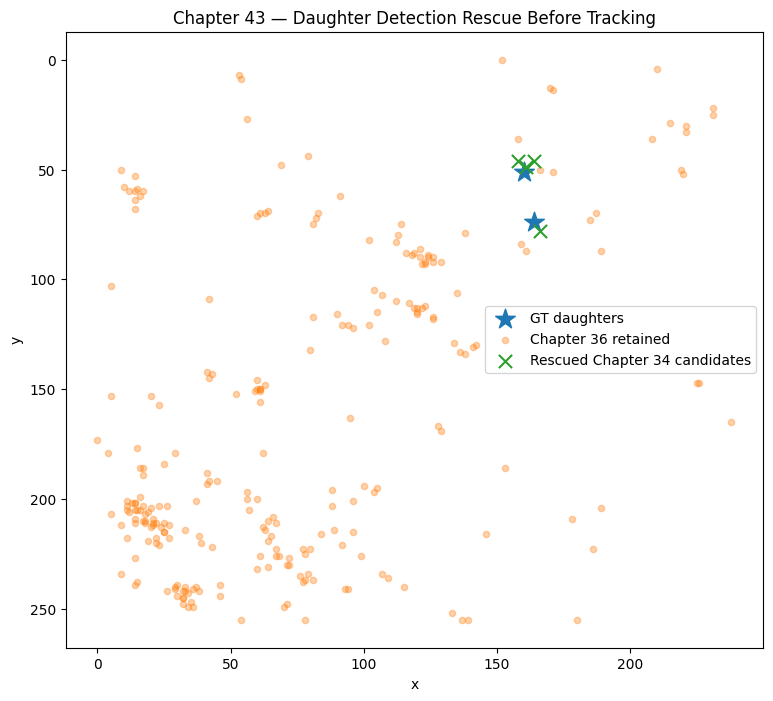

In [13]:

plt.figure(figsize=(9,8))
plt.scatter([division["daughter_a_x"],division["daughter_b_x"]],[division["daughter_a_y"],division["daughter_b_y"]],marker="*",s=220,label="GT daughters")
local36=chapter36_df[chapter36_df["t"].between(CONFIG.trace_start_t,CONFIG.trace_end_t)]
plt.scatter(local36["x"],local36["y"],s=20,alpha=0.35,label="Chapter 36 retained")
if not rescued_detections_df.empty:
    plt.scatter(rescued_detections_df["x"],rescued_detections_df["y"],marker="x",s=90,label="Rescued Chapter 34 candidates")
plt.gca().invert_yaxis()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Chapter 43 — Daughter Detection Rescue Before Tracking")
plt.legend()
plt.show()

## Step 12 — Validation

In [14]:

validation_rows=[
    {"check":"gt_division_found","passed":len(gt_divisions_df)>0,"details":f"{len(gt_divisions_df)} GT division(s)"},
    {"check":"chapter34_loaded","passed":len(chapter34_df)>0,"details":f"{len(chapter34_df)} rows"},
    {"check":"chapter36_loaded","passed":len(chapter36_df)>0,"details":f"{len(chapter36_df)} rows"},
    {"check":"rescue_audit_created","passed":not filtered_out_audit_df.empty,"details":f"{len(filtered_out_audit_df)} nearby Chapter 34 candidates"},
    {"check":"rescued_set_created","passed":len(chapter43_rescued_detection_set_df)>=len(chapter36_df),"details":f"{len(chapter43_rescued_detection_set_df)} detections"},
]
rescue_validation_df=pd.DataFrame(validation_rows)
display(rescue_validation_df)
print("Chapter 43 validation passed." if rescue_validation_df["passed"].all() else "Chapter 43 completed with diagnostics needing review.")

,check,passed,details
0,gt_division_found,True,1 GT division(s)
1,chapter34_loaded,True,20000 rows
2,chapter36_loaded,True,5000 rows
3,rescue_audit_created,True,6 nearby Chapter 34 candidates
4,rescued_set_created,True,5004 detections


Chapter 43 validation passed.


## Step 13 — Save outputs

In [15]:

output_paths={
    "audit":OUTPUT_DIR/"chapter43_daughter_candidate_audit.csv",
    "filtered_out":OUTPUT_DIR/"chapter43_filtered_out_daughter_candidates.csv",
    "rescued":OUTPUT_DIR/"chapter43_rescued_detections.csv",
    "rescued_set":OUTPUT_DIR/"chapter43_rescued_detection_set.csv",
    "summary":OUTPUT_DIR/"chapter43_rescue_summary.csv",
    "validation":OUTPUT_DIR/"chapter43_rescue_validation.csv",
    "gt_division":OUTPUT_DIR/"chapter43_gt_division.csv",
}
tables_to_save={
    "audit":daughter_candidate_audit_df,
    "filtered_out":filtered_out_audit_df,
    "rescued":rescued_detections_df,
    "rescued_set":chapter43_rescued_detection_set_df,
    "summary":rescue_summary_df,
    "validation":rescue_validation_df,
    "gt_division":gt_divisions_df,
}
for key,table in tables_to_save.items():
    path=output_paths[key]
    table.to_csv(path,index=False)
    print(f"Saved {path.name}: {len(table):,} rows")

Saved chapter43_daughter_candidate_audit.csv: 160 rows
Saved chapter43_filtered_out_daughter_candidates.csv: 6 rows
Saved chapter43_rescued_detections.csv: 4 rows
Saved chapter43_rescued_detection_set.csv: 5,004 rows
Saved chapter43_rescue_summary.csv: 2 rows
Saved chapter43_rescue_validation.csv: 5 rows
Saved chapter43_gt_division.csv: 1 rows


## Step 14 — Create ZIP

In [16]:
# ============================================================
# FIX — Remove failed Chapter 43 ZIP and check disk space
# ============================================================

from pathlib import Path
import shutil

OUTPUT_DIR = Path("/kaggle/working")

broken_zip = OUTPUT_DIR / "chapter43_outputs.zip"

if broken_zip.exists():
    size_mb = broken_zip.stat().st_size / (1024 ** 2)
    print(f"Removing failed ZIP: {broken_zip}")
    print(f"Failed ZIP size: {size_mb:.2f} MB")
    broken_zip.unlink()
else:
    print("No failed Chapter 43 ZIP found.")

total, used, free = shutil.disk_usage("/kaggle/working")

print()
print(f"Disk free: {free / (1024**3):.2f} GB")

No failed Chapter 43 ZIP found.

Disk free: 19.50 GB


In [17]:
# ============================================================
# FINAL STEP — Package ONLY Chapter 43 outputs
# ============================================================

from pathlib import Path
import zipfile
import pandas as pd

OUTPUT_DIR = Path("/kaggle/working")
ZIP_PATH = OUTPUT_DIR / "chapter43_outputs.zip"

# Find Chapter 43 output files only.
# Exclude the ZIP itself so we never try to zip a zip into itself.
chapter43_files = sorted([
    path
    for path in OUTPUT_DIR.glob("chapter43_*")
    if path.is_file()
    and path.name != ZIP_PATH.name
    and path.suffix.lower() != ".zip"
])

print("Chapter 43 files to package:")
print()

for path in chapter43_files:
    size_kb = path.stat().st_size / 1024
    print(f"  {path.name:<55} {size_kb:10.1f} KB")

print()
print("Total files:", len(chapter43_files))

if not chapter43_files:
    raise RuntimeError(
        "No Chapter 43 output files were found in /kaggle/working."
    )

# Remove an old/partial ZIP if one exists
if ZIP_PATH.exists():
    ZIP_PATH.unlink()

# Create a ZIP containing ONLY Chapter 43 files
with zipfile.ZipFile(
    ZIP_PATH,
    mode="w",
    compression=zipfile.ZIP_DEFLATED,
    allowZip64=True,
) as zip_file:

    for path in chapter43_files:
        zip_file.write(
            path,
            arcname=path.name,
        )

print()
print("=" * 70)
print("CHAPTER 43 OUTPUT PACKAGE CREATED")
print("=" * 70)

print("ZIP:", ZIP_PATH)
print(f"ZIP size: {ZIP_PATH.stat().st_size / (1024**2):.2f} MB")

# Verification table
created_files = chapter43_files + [ZIP_PATH]

verification_df = pd.DataFrame([
    {
        "filename": path.name,
        "size_bytes": path.stat().st_size,
        "size_mb": path.stat().st_size / (1024**2),
        "exists": path.exists(),
    }
    for path in created_files
])

display(verification_df)

Chapter 43 files to package:

  chapter43_daughter_candidate_audit.csv                       131.8 KB
  chapter43_filtered_out_daughter_candidates.csv                 4.0 KB
  chapter43_gt_division.csv                                      0.3 KB
  chapter43_rescue_summary.csv                                   0.3 KB
  chapter43_rescue_validation.csv                                0.2 KB
  chapter43_rescued_detection_set.csv                         4731.8 KB
  chapter43_rescued_detections.csv                               3.1 KB

Total files: 7

CHAPTER 43 OUTPUT PACKAGE CREATED
ZIP: /kaggle/working/chapter43_outputs.zip
ZIP size: 1.80 MB


,filename,size_bytes,size_mb,exists
0,chapter43_daughter_candidate_audit.csv,134922,0.128672,True
1,chapter43_filtered_out_daughter_candidates.csv,4071,0.003882,True
2,chapter43_gt_division.csv,274,0.000261,True
3,chapter43_rescue_summary.csv,331,0.000316,True
4,chapter43_rescue_validation.csv,224,0.000214,True
5,chapter43_rescued_detection_set.csv,4845321,4.620858,True
6,chapter43_rescued_detections.csv,3140,0.002995,True
7,chapter43_outputs.zip,1888165,1.800694,True


# Chapter 43 Complete

This notebook answers:

> Can useful daughter detections be recovered before tracking?

Interpret the rescue summary:

- If `rescued_best_distance` improves substantially over `chapter36_best_distance`, Chapter 36 filtering is confirmed as a major source of daughter recall loss.
- If Daughter B remains weak even after rescue, the detector itself needs improvement or a temporal look-ahead rule.
- If both daughters become spatially plausible after rescue, the next chapter should rerun tracking from this rescued detection set.

## Save

Preserve:

```text
chapter43_rescued_detections.csv
chapter43_rescued_detection_set.csv
chapter43_rescue_summary.csv
chapter43_outputs.zip
```

## Next chapter

**Chapter 44 — Re-Track with Rescued Division Daughters**